In [2]:
%store -r x
%store -r y

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
x.head()

,00,01,02,03,04,05,06,07,08,09,...,40,41,42,43,44,45,46,47,48,49
0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,43.896138,...,140.957957,69.511954,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196
1,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,26.967553,...,148.975866,92.131989,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485
2,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,45.272021,...,94.262093,86.164997,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027
3,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,11.692485,...,154.828040,32.473642,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484
4,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,43.643912,...,137.733814,37.866648,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952


Poderia ter sido usado outro modelo, definindo anteriormente as melhores variáveis e modelando a partir delas. Isso traria mais rapidez ao modelo, porém ao utilizar o modelo
de random forest, podemos deixar com que a máquina olhe todos os resultados, e que apesar de necessitar de mais tempo para a geração, ela poderá detectar as variáveis mais importantes e ainda obter bons valores de parâmetros para a avaliação. Um exemplo daquele que mais fará diferença é o valor de recall, que visualiza melhor os valores de sensibilidade, visto que é melhor identificar algumas vezes como falha algo que está funcionando do que muitas vezes definir como normal uma falha que afetaria toda a máquina. 

In [4]:
#Feito a divisão do teste e treino da base.
#O parâmetro 'stratify=y' garante que a mesma proporção de falhas vá para o treino e para o teste.
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

#class_weight='balanced' dá um peso muito maior para a classe minoritária, ou seja, as falhas.
#Isso leva ao modelo prestar mais atenção no valor do recall, prevendo melhor as falhas.
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

#Não utilizei valores altos devido a demora de teste
param_grid = {
    'n_estimators': [50, 100],        #Quantidade de árvores na floresta
    'max_depth': [5, 10],       #Profundidade máxima de cada árvore
    'min_samples_split': [10, 20]    #Mínimo de amostras para dividir um nó
}

#GridSearchCV fará a seleção do melhor modelo e utilizando o scoring='recall' para escolher a que encontra o melhor valor para o mesmo
grid_search = GridSearchCV(estimator=base_rf, 
                           param_grid=param_grid, 
                           scoring='recall', 
                           cv=5,        #Validação cruzada em 5 partes
                           n_jobs=-1)   #Usa todos os núcleos do seu processador para ir mais rápido

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10], 'min_samples_split': [10, 20], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [5]:
#Avaliando o modelo vencedor
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Melhores Parâmetros encontrados:", grid_search.best_params_)
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

#Nesse modelo, a busca pelo recall foi o mais importante visto que é necessário encontrar 

Melhores Parâmetros encontrados: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 100}

Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     61751
           1       0.72      0.98      0.83      4345

    accuracy                           0.97     66096
   macro avg       0.86      0.98      0.91     66096
weighted avg       0.98      0.97      0.98     66096



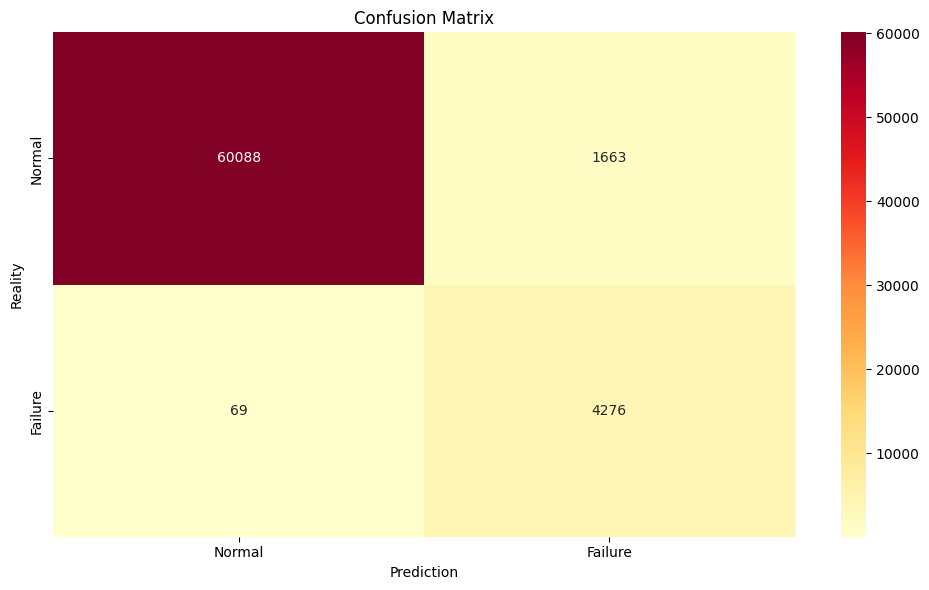

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Calcula a matriz usando as previsões do código anterior
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))

# fmt='g' evita que os números fiquem em notação científica (ex: 1e+03)
sns.heatmap(cm, annot=True, fmt='g', cmap='YlOrRd', 
            xticklabels=['Normal', 'Failure'], 
            yticklabels=['Normal', 'Failure'])

plt.title('Confusion Matrix')
plt.ylabel('Reality')
plt.xlabel('Prediction')
plt.tight_layout()
plt.savefig('modelling_plots/confusion_matrix.png')
plt.show()

C:\Users\André\AppData\Local\Temp\ipykernel_11752\2275598349.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Significance', y='Sensor', data=df_top15, palette='YlOrRd')


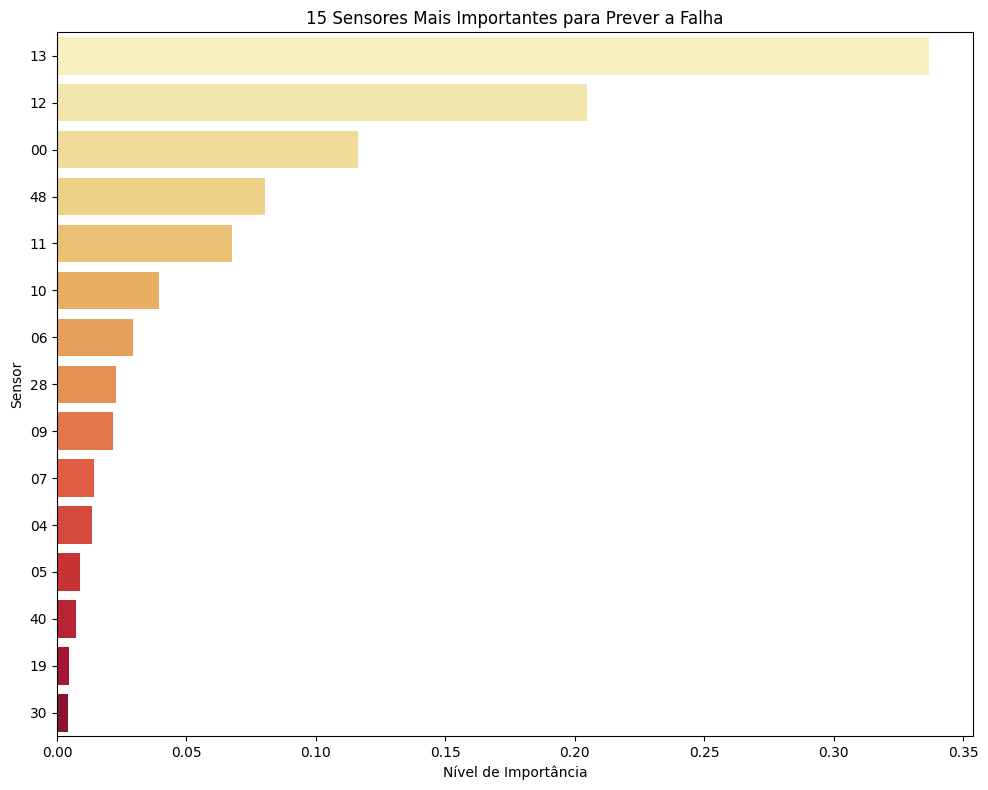

In [7]:

#Extrai a importância de cada sensor do modelo treinado
significance = best_rf.feature_importances_

#Cria um DataFrame associando o nome da coluna com seu valor de importância
significance_df = pd.DataFrame({
    'Sensor': X_train.columns,
    'Significance': significance
})

#Pegamos apenas as 15 principais
df_top15 = significance_df.sort_values(by='Significance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Significance', y='Sensor', data=df_top15, palette='YlOrRd')

plt.title('15 Sensores Mais Importantes para Prever a Falha')
plt.xlabel('Nível de Importância')
plt.ylabel('Sensor')

plt.tight_layout()
plt.savefig('modelling_plots/best_sensors.png')
plt.show()

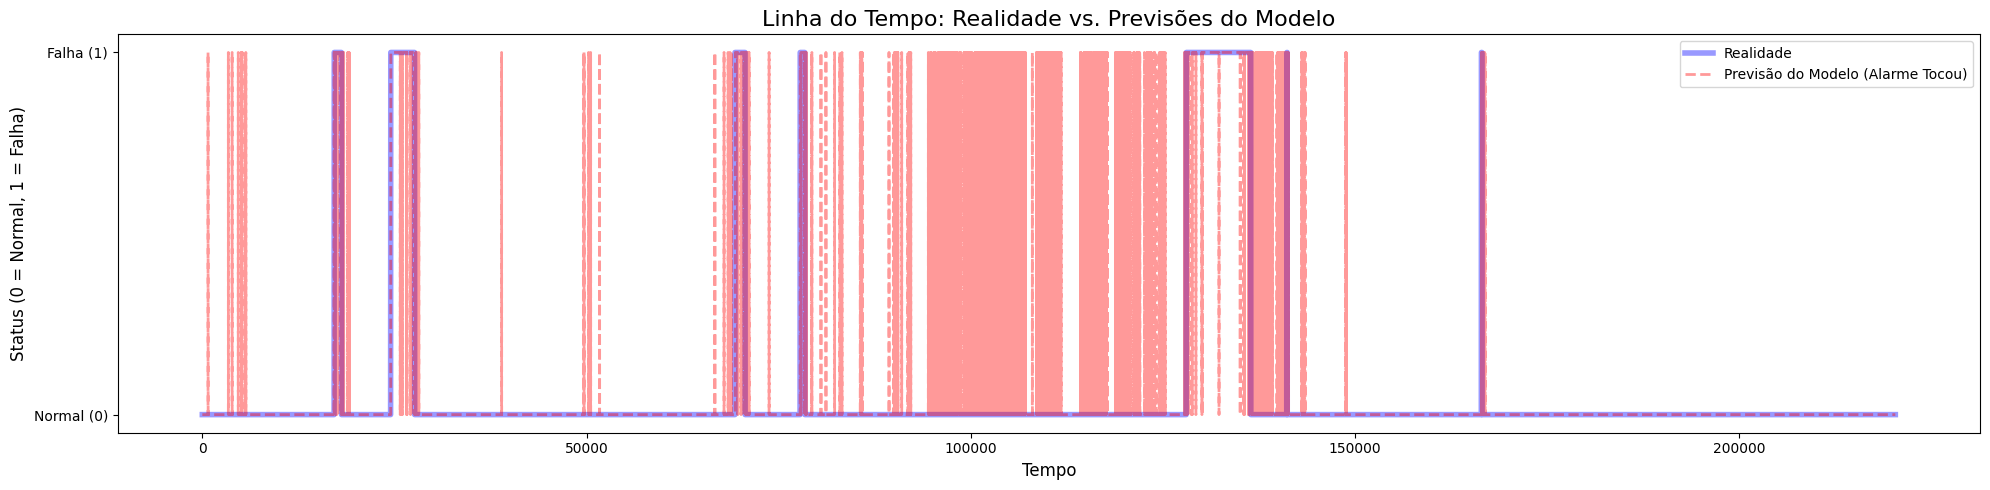

In [13]:

#Unimos o que aconteceu de verdade (y_test) com a previsão do modelo (y_pred)
results = pd.DataFrame({
    'real_status': y_test,
    'model_prediction': y_pred
}, index=y_test.index)

#Ordenamos pelo índice para a linha do tempo fazer sentido
results = results.sort_index()

plt.figure(figsize=(20, 5))

#Plota a realidade como uma linha contínua azul
plt.plot(results.index, results['real_status'], 
         label='Realidade', color='blue', alpha=0.4, linewidth=4)

#Plota a previsão do modelo como pontos/traços vermelhos por cima
plt.plot(results.index, results['model_prediction'], 
         label='Previsão do Modelo (Alarme Tocou)', color='red', linestyle='--', alpha=0.4, linewidth=2)

plt.title('Linha do Tempo: Realidade vs. Previsões do Modelo', fontsize=16)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Status (0 = Normal, 1 = Falha)', fontsize=12)

#Coloca os valores do eixo Y apenas como 0 e 1 para ficar limpo
plt.yticks([0, 1], ['Normal (0)', 'Falha (1)'])
plt.legend()
plt.tight_layout()
plt.savefig('modelling_plots/failures_predictions.png')
plt.show()

<Figure size 1000x800 with 0 Axes>

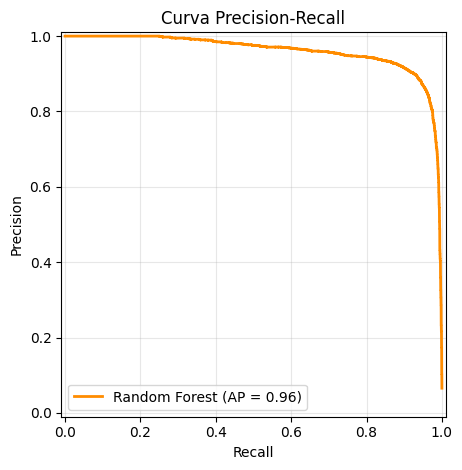

In [ ]:
plt.figure(figsize=(10, 8))

#Passo o modelo treinado (best_rf), os dados de teste e o eixo
display = PrecisionRecallDisplay.from_estimator(
    best_rf, X_test, y_test, 
    name="Random Forest",
    color="darkorange",
    linewidth=2
)

plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('modelling_plots/precision_recall.png')
plt.show()